# **Meshlands - Atmospheric Circulation**
This notebook presents transport-related results and analysis. It is organized as:
- Wind (vertical ascent, meridional and zonal wind),
- Meridional water transport,
- Meridional Heat transport.

## **Initial Set Up-related**

### Imports

In [16]:
%matplotlib inline
import sys
sys.path.append('./scripts')

########## Plotting (Matplotlib) ##########
import matplotlib.pyplot as plt

########## Python Standard Library ##########
from copy import copy
import glob

########## Dask ##########
import dask

########## NumPy ##########
import numpy as np

########## Xarray ##########
import xarray as xr

### Function Definitions

In [17]:
def mean(ds_case,mask):
    '''
    Calculates the global, ocean and land mean of a given variable for a given configuration.

    Args:
        ds_case (xarray): dictionnary containing lat and lon dimensions.
        mask (list): representation of continental distribution, with value 1 if land and value 0 if ocean.
        var (str): name of the variable that needs to be averaged.

    Returns:
        gm (float OR array): global mean (can be an array if ds_case contains others dimensions).
        lm (float OR array): land mean (can be an array if ds_case contains others dimensions).
        om (float OR array): ocean mean (can be an array if ds_case contains others dimensions).
    '''
    # Collects the datas to plot the surface temperature
    mapdata = (ds_case['TS'].mean('year'))
    
    # Weights the latitude, renames it to "weights", then prints the value
    weights = np.cos(np.deg2rad(ds_case['TS'].lat))
    weights.name = "weights"
    
    # Finds the weighted global mean based on latitude and longitude
    gm = mapdata.weighted(weights).mean(('lat', 'lon')).values

    # Defines a land timeseries where the land mask is present
    land = mapdata.where(mask == 1)

    # Defines an ocean timeseries where the land mask is not present (i.e. just ocean/water)
    ocean = mapdata.where(mask != 1)

    # Mean Land
    lm = land.weighted(weights).mean(('lat', 'lon')).values

    # Mean Ocean
    om = ocean.weighted(weights).mean(('lat', 'lon')).values

    return gm, lm, om

### Path Definitions

In [18]:
# Data Path
data_dir = '/scratch/st-mlague-1/mlague/data/cesm_meshland/'

### Variable Definitions

In [19]:
# Creates a list of atmospheric variables
atm_vars = ['PS','U','V','VQ','VT','OMEGA','Z3']

### Dictionary Definitions

In [20]:
# Creates a new case list
case_list = ['cesm_f09_mesh4_avgemiss_450ppm_thermice2',
             'cesm_f09_mesh8_avgemiss_450ppm_thermice2',
             'cesm_f09_mesh16_avgemiss_450ppm_thermice2']

# Creates a dictionary of the short names for each case in case_list
short_names = {}
short_names['cesm_f09_mesh4_avgemiss_450ppm_thermice2'] = 'mesh4'
short_names['cesm_f09_mesh8_avgemiss_450ppm_thermice2'] = 'mesh8'
short_names['cesm_f09_mesh16_avgemiss_450ppm_thermice2'] = 'mesh16'

# create a list of cases
config = list(short_names.values())

In [21]:
# Creates an empty data set dictionary
ds_dict = {}

# Creates an empty time series dictionary for the atmospheric variables
ts_dict_atm = {}

# Creates an empty dictionary for the meshlands geographical configuration
mesh_dict = {}
mesh4_dict = xr.open_dataset("/scratch/st-mlague-1/mlague/data/cesm_meshland/inputs/fracdata_0.9x1.25_meshland4.nc")
mesh8_dict = xr.open_dataset("/scratch/st-mlague-1/mlague/data/cesm_meshland/inputs/fracdata_0.9x1.25_meshland8.nc")
mesh16_dict = xr.open_dataset("/scratch/st-mlague-1/mlague/data/cesm_meshland/inputs/fracdata_0.9x1.25_meshland16.nc")
mesh_dict['mesh4'] = mesh4_dict
mesh_dict['mesh8'] = mesh8_dict
mesh_dict['mesh16'] = mesh16_dict

# Overall: using dask to split large chunks of the array to avoid a surcharge
with dask.config.set(**{'array.slicing.split_large_chunks': True}):

    # For each case in the case list,
    # prints the name of the case
    for case in case_list:
        print(case)

        # Defines the time series directory name for the case
        ts_dir = data_dir + '/' + case + '/TimeSeries/'

        # Creates an empty file list for the atmospheric variables
        file_list_atm = []

        # For each variable in the set of atmospheric variables
        for var in atm_vars:

            # Finds the variable's file for that case
            files = glob.glob(ts_dir+'/'+case+'.cam.h0.ts.0-end.'+var+'.nc')

            # If the file does not exist, print a message
            # Else, append the files to the atmospheric file list
            if len(files)<1:
                print('oh no, no variables for %s'%var)
            else:
                for file in files:
                    file_list_atm.append(file)

        # Creates temporary atmospheric and land data sets
        ds_temp_atm = xr.open_mfdataset(file_list_atm,engine='netcdf4',compat='override')

        # Drops the first 30 years, and keeps data up to year 60
        if case == 'cesm_f09_mesh16_avgemiss_450ppm_thermice2':
            ds_temp_atm_short = ds_temp_atm.isel(time=slice((27-1)*12-1,56*12-1))
        else:
            ds_temp_atm_short = ds_temp_atm.isel(time=slice((30-1)*12-1,60*12-1))

        # Assigns the case's short name to short
        short = short_names[case]

        # Creates a copy of the temporary atmospheric and land data sets,
        # then assigns them to an entry in their respective dictionaries
        ts_dict_atm[short] = copy(ds_temp_atm_short)

        # Deletes the temporary data sets
        del ds_temp_atm, ds_temp_atm_short

cesm_f09_mesh4_avgemiss_450ppm_thermice2
cesm_f09_mesh8_avgemiss_450ppm_thermice2
cesm_f09_mesh16_avgemiss_450ppm_thermice2


# **Wind**

## **Vertical Velocity**

### vertical ascent over land

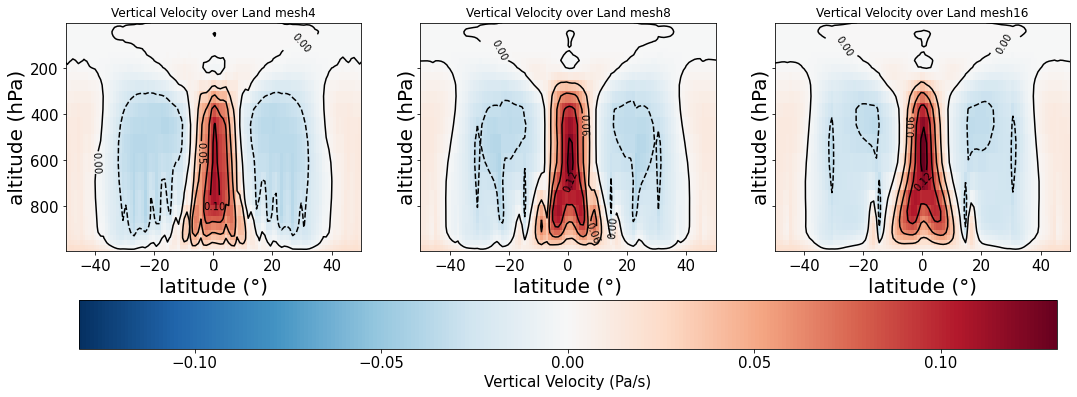

In [22]:
# Overall: plots the vertical velocity of the air over continents only

# Creates an empty list to contain the data
plot_data = []
for case in config :
    # Groups the case's atmospheric time series dictionary by year, calculates the mean
    ds_case = ts_dict_atm[case].groupby('time.year').mean('time')
    
    # Collects the case mask to keep only land values
    mask = mesh_dict[case]['mask'].values
    omega = -ds_case['OMEGA'].mean('year')
    omega_land = omega.where(mask == 1).mean('lon')
    
    plot_data.append((case,omega_land))

# Shared colour limits for the same scale across all plots
# Calculates the min and max value of all omega for the colorbar
vmin = min(float(omega.min().values) for (case, omega) in plot_data)
vmax = max(float(omega.max().values) for (case, omega) in plot_data)
lim = max(abs(vmin),abs(vmax))

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for ax, (case, omega) in zip(axes, plot_data):
    lat = omega['lat']
    lev = omega['lev']

    # Draws contours
    cs = ax.contour(lat, lev, omega, levels=5, linestyles=None, colors='k')
    ax.clabel(cs, levels=cs.levels[::2], fmt="%.2f", fontsize=10, inline=True)
    
    # Draws the colormap
    im = ax.pcolormesh(lat, lev, omega, cmap='RdBu_r', vmin=-lim, vmax=lim, shading='auto')
    
    ax.set_title(f'Vertical Velocity over Land {case}')
    ax.set_xlabel('latitude (°)',fontsize=20)
    ax.set_xlim([-50,50])
    ax.set_ylabel('altitude (hPa)',fontsize=20)
    ax.tick_params(labelsize=15)
    # Reverts y-axis
    ax.set_ylim(lev.max().values, lev.min().values)

# Manages positioning and display of the colorbar
cb = fig.colorbar(im, ax=axes, orientation='horizontal')
cb.set_label('Vertical Velocity (Pa/s)',fontsize=15)
cb.ax.tick_params(labelsize=15)

plt.show()
plt.close()

### vertical ascent over ocean

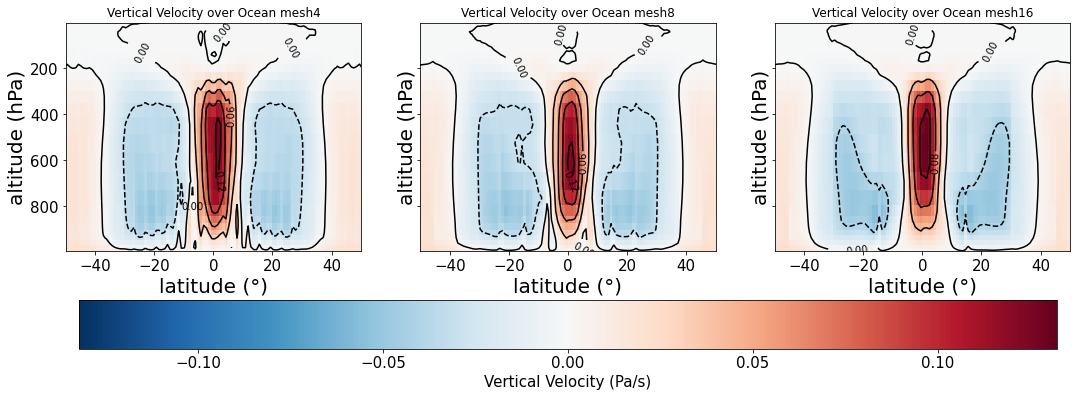

In [23]:
# Overall: plots the vertical velocity of the air over oceans only

# Creates an empty list to contain the data
plot_data = []
for case in config :
    # Groups the case's atmospheric time series dictionary by year, calculates the mean
    ds_case = ts_dict_atm[case].groupby('time.year').mean('time')

    # Collects the case mask to keep only ocean values
    mask = mesh_dict[case]['mask'].values
    omega = -ds_case['OMEGA'].mean('year')
    omega_ocean = omega.where(mask == 0).mean('lon')
    
    plot_data.append((case,omega_ocean))

# Shared colour limits for the same scale across all plots
# Calculates the min and max value of all omega for the colorbar
vmin = min(float(omega.min().values) for (case, omega) in plot_data)
vmax = max(float(omega.max().values) for (case, omega) in plot_data)
lim = max(abs(vmin),abs(vmax))

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for ax, (case, omega) in zip(axes, plot_data):
    lat = omega['lat']
    lev = omega['lev']

    # Draws contours
    cs = ax.contour(lat, lev, omega, levels=5, linestyles=None, colors='k')
    ax.clabel(cs, levels=cs.levels[::2], fmt="%.2f", fontsize=10, inline=True)
    
    # Draws the colormap
    im = ax.pcolormesh(lat, lev, omega, cmap='RdBu_r', vmin=-lim, vmax=lim, shading='auto')
    
    ax.set_title(f'Vertical Velocity over Ocean {case}')
    ax.set_xlabel('latitude (°)',fontsize=20)
    ax.set_xlim([-50,50])
    ax.set_ylabel('altitude (hPa)',fontsize=20)
    ax.tick_params(labelsize=15)
    # Reverts y-axis
    ax.set_ylim(lev.max().values, lev.min().values)

# Manages positioning and display of the colorbar
cb = fig.colorbar(im, ax=axes, orientation='horizontal')
cb.set_label('Vertical Velocity (Pa/s)',fontsize=15)
cb.ax.tick_params(labelsize=15)

plt.show()
plt.close()

### Delta Land/Ocean vertical ascent

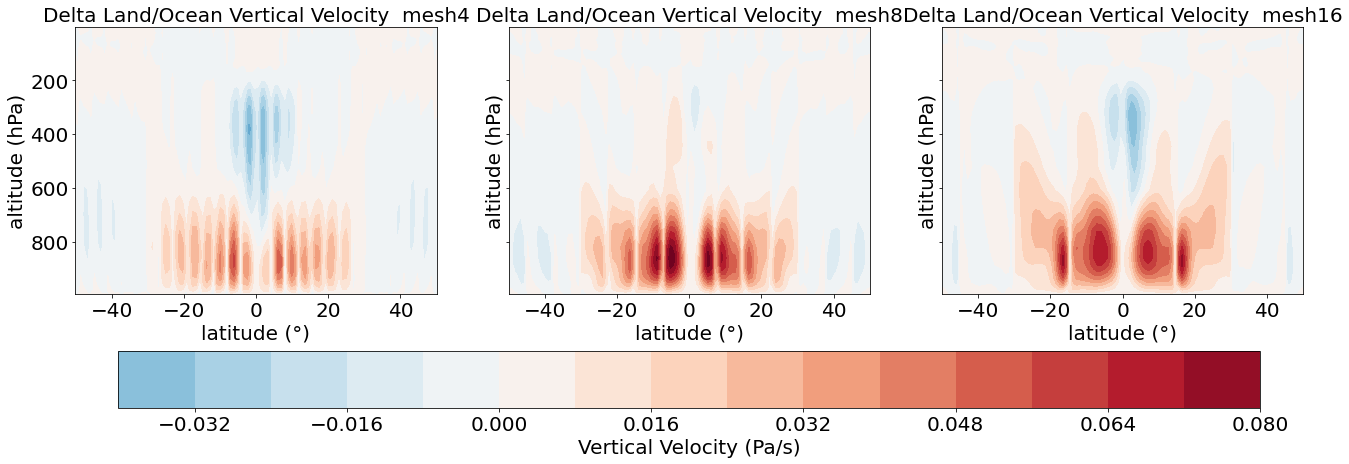

In [24]:
# Plots the differences in land/ocean vertical motion

# Creates an empty list to store data
plot_data = []
for case in config :
    # Groups the case's atmospheric time series dictionary by year, calculates the mean
    ds_case = ts_dict_atm[case].groupby('time.year').mean('time')

    # Collects case mask data to isolate land values and ocean values
    mask = mesh_dict[case]['mask'].values
    omega = -ds_case['OMEGA'].mean('year')
    omega_ocean = omega.where(mask == 0).mean('lon')
    omega_land = omega.where(mask == 1).mean('lon')
    
    plot_data.append((case,omega_land - omega_ocean))

# Shared colour limits for the same scale across all plots
# Calculates the min and max value of all omega for the colorbar
vmin = min(float(omega.min().values) for (case, omega) in plot_data)
vmax = max(float(omega.max().values) for (case, omega) in plot_data)
lim = max(abs(vmin),abs(vmax))

fig, axes = plt.subplots(1, 3, figsize=(22, 7), sharey=True)

for ax, (case, omega) in zip(axes, plot_data):
    lat = omega['lat']
    lev = omega['lev']
    
    # Draws the colormap
    im = ax.contourf(lat, lev, omega, levels=15, cmap='RdBu_r', vmin=-lim, vmax=lim)
    
    ax.set_title(f'Delta Land/Ocean Vertical Velocity  {case}', fontsize=20)
    ax.set_xlabel('latitude (°)',fontsize=20)
    ax.set_xlim([-50,50])
    ax.set_ylabel('altitude (hPa)',fontsize=20)
    ax.tick_params(labelsize=20)
    # Reverts the y-axis
    ax.set_ylim(lev.max().values, lev.min().values)

# Manages positioning and display of the colorbar
cb = fig.colorbar(im, ax=axes, orientation='horizontal')
cb.set_label('Vertical Velocity (Pa/s)',fontsize=20)
cb.ax.tick_params(labelsize=20)

plt.show()
plt.close()

## **Zonal Wind**

### **Zonal Wind (longitude-averaged)**

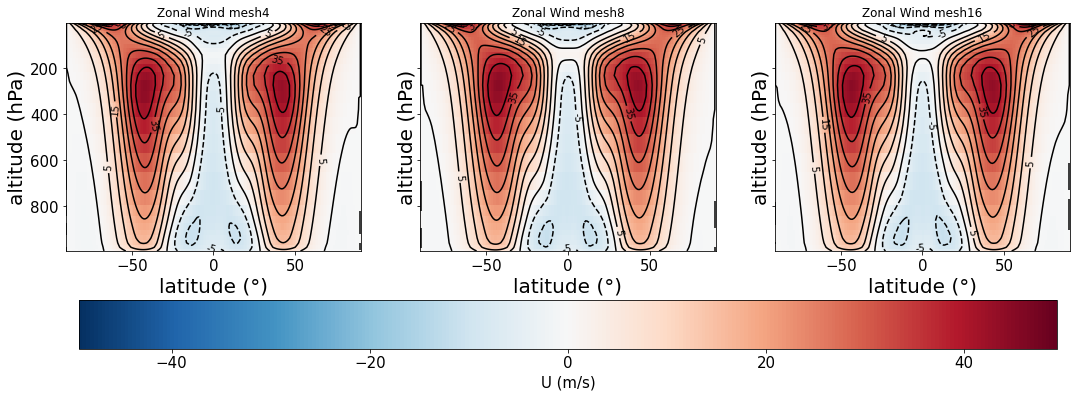

In [25]:
# Overall: creates 3 plots to show Zonal Wind at each latitude and altitude (mean by longitude)

# Creates an empty list to store data
plot_data = []
for case in config :
    # Groups the case's atmospheric time series dictionary by year, calculates the mean
    ds_case = ts_dict_atm[case].groupby('time.year').mean('time')
    U = ds_case['U'].mean('year').mean('lon')
    plot_data.append((case,U))

# Shared colour limits for the same scale across all plots
# Calculates the min and max value of all U for the colorbar
vmin = min(float(U.min().values) for (case, U) in plot_data)
vmax = max(float(U.max().values) for (case, U) in plot_data)
lim = max(abs(vmin),abs(vmax))

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for ax, (case, U) in zip(axes, plot_data):
    lat = U['lat']
    lev = U['lev']

    # Draws contours
    cs = ax.contour(lat, lev, U, levels=20, linestyles=None, colors='k')
    ax.clabel(cs, levels=cs.levels[::2], fmt="%d", fontsize=10, inline=True)
    
    # Draws the colormap
    im = ax.pcolormesh(lat, lev, U, cmap='RdBu_r', vmin=-lim, vmax=lim, shading='auto')

    ax.set_title(f'Zonal Wind {case}')
    ax.set_xlabel('latitude (°)',fontsize=20)
    ax.set_ylabel('altitude (hPa)',fontsize=20)
    ax.tick_params(labelsize=15)
    # Reverts y-axis
    ax.set_ylim(lev.max().values, lev.min().values)

# Manages positioning and display of the colorbar
cb = fig.colorbar(im, ax=axes, orientation='horizontal')
cb.set_label('U (m/s)',fontsize=15)
cb.ax.tick_params(labelsize=15)

plt.show()
plt.close()

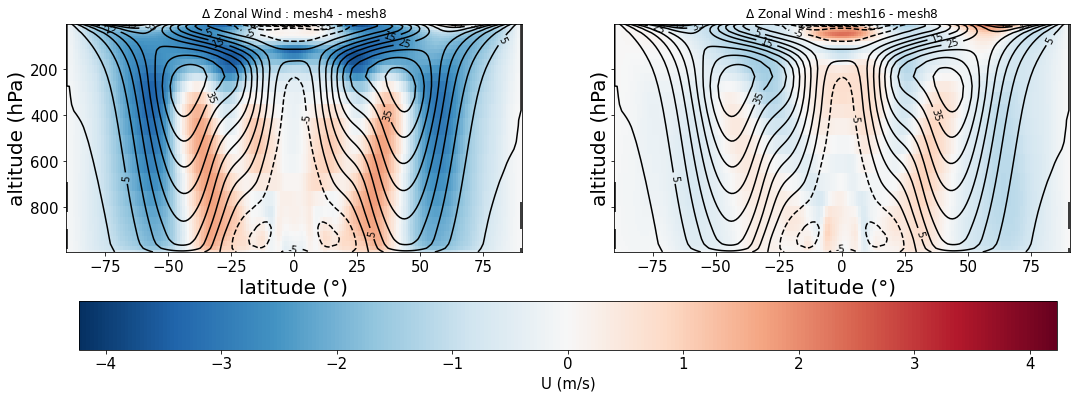

In [26]:
# Overall: creates 2 plots to show Zonal Wind differences with a reference case (mean by longitude)

# Calculates the reference case
ds8 = ts_dict_atm['mesh8'].groupby('time.year').mean('time')
ref = ds8['U'].mean('year').mean('lon')

# Creates an empty list to store data
plot_data = []
for case in ['mesh4','mesh16'] :
    # Groups the case's atmospheric time series dictionary by year, calculates the mean
    ds_case = ts_dict_atm[case].groupby('time.year').mean('time')
    U = ds_case['U'].mean('year').mean('lon') - ref
    plot_data.append((case,U))

# Shared colour limits for the same scale across all plots
# Calculates the min and max value of all U for the colorbar
vmin = min(float(U.min().values) for (case, U) in plot_data)
vmax = max(float(U.max().values) for (case, U) in plot_data)
lim = max(abs(vmin),abs(vmax))

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

for ax, (case, U) in zip(axes, plot_data):
    lat = U['lat']
    lev = U['lev']

    # Draws contours
    cs = ax.contour(lat, lev, ref, levels=20, linestyles=None, colors='k')
    ax.clabel(cs, levels=cs.levels[::2], fmt="%d", fontsize=10, inline=True)
    
    # Draws the colormap
    im = ax.pcolormesh(lat, lev, U, cmap='RdBu_r', vmin=-lim, vmax=lim, shading='auto')
    
    ax.set_title(f'$\Delta$ Zonal Wind : {case} - mesh8')
    ax.set_xlabel('latitude (°)',fontsize=20)
    ax.set_ylabel('altitude (hPa)',fontsize=20)
    ax.tick_params(labelsize=15)
    # Reverts y-axis
    ax.set_ylim(lev.max().values, lev.min().values)

# Manages colorbar
cb = fig.colorbar(im, ax=axes, orientation='horizontal')
cb.set_label('U (m/s)',fontsize=15)
cb.ax.tick_params(labelsize=15)

plt.show()
plt.close()

## **Meridional Wind**

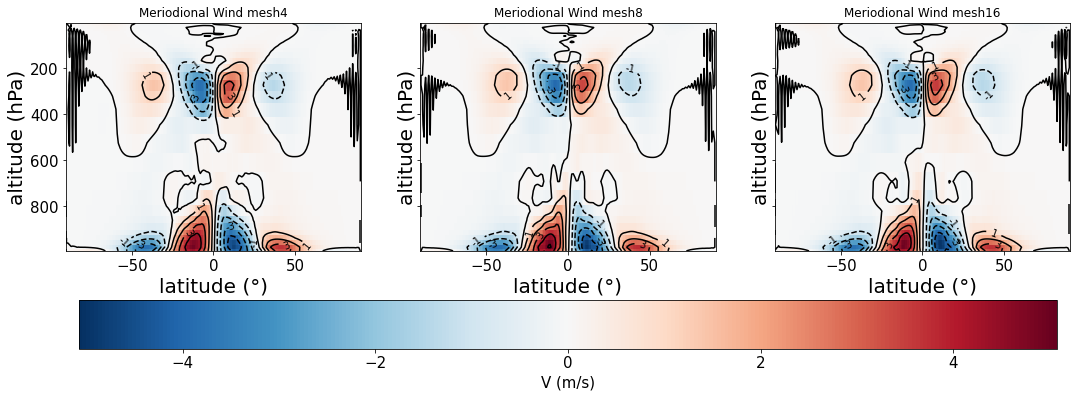

In [27]:
# Overall: creates 3 plots to show Meridional Wind at each latitude and altitude (mean by longitude)

# Creates an empty list to store data
plot_data = []
for case in config :
    # Groups the case's atmospheric time series dictionary by year, calculates the mean
    ds_case = ts_dict_atm[case].groupby('time.year').mean('time')
    V = ds_case['V'].mean('year').mean('lon')
    plot_data.append((case,V))

# Shared colour limits for the same scale across all plots
# Calculates the min and max value of all V for the colorbar
vmin = min(float(V.min().values) for (case, V) in plot_data)
vmax = max(float(V.max().values) for (case, V) in plot_data)
lim = max(abs(vmin),abs(vmax))

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for ax, (case, V) in zip(axes, plot_data):
    lat = V['lat']
    lev = V['lev']

    # Draws contours
    cs = ax.contour(lat, lev, V, levels=10, linestyles=None, colors='k')
    ax.clabel(cs, levels=cs.levels[::2], fmt="%d", fontsize=10, inline=True)
    
    # Draws the colormap
    im = ax.pcolormesh(lat, lev, V, cmap='RdBu_r', vmin=-lim, vmax=lim, shading='auto')
    
    ax.set_title(f'Meriodional Wind {case}')
    ax.set_xlabel('latitude (°)',fontsize=20)
    ax.set_ylabel('altitude (hPa)',fontsize=20)
    ax.tick_params(labelsize=15)
    # Reverts y-axis
    ax.set_ylim(lev.max().values, lev.min().values)

# Manages colorbar
cb = fig.colorbar(im, ax=axes, orientation='horizontal')
cb.set_label('V (m/s)',fontsize=15)
cb.ax.tick_params(labelsize=15)

plt.show()
plt.close()

# **Meridional water transport**

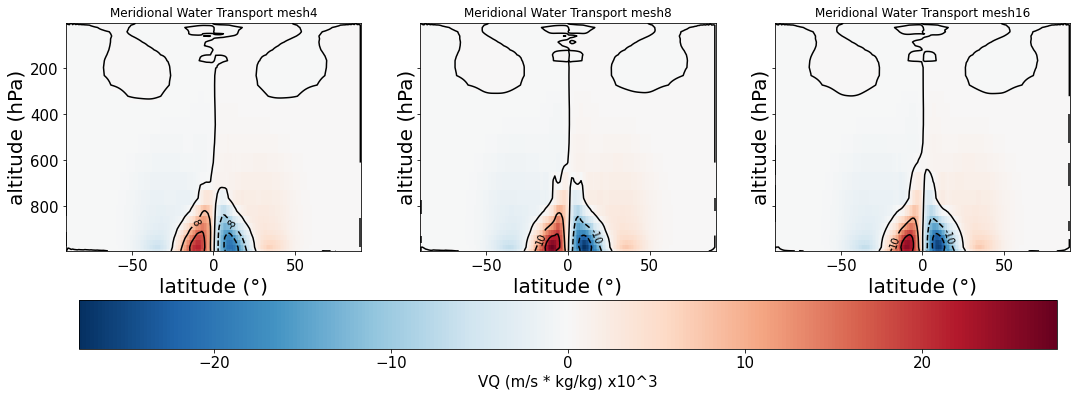

In [28]:
# Overall: plots separately the meridional water transport vertical evolution for each case

# Creates an empty list to store data
plot_data = []
for case in config :
    # Groups the case's atmospheric time series dictionary by year, calculates the mean
    ds_case = ts_dict_atm[case].groupby('time.year').mean('time')
    VQ = ds_case['VQ'].mean('year').mean('lon')
    plot_data.append((case,VQ))

# Shared colour limits for the same scale across all plots
# Calculates the min and max value of all VQ for the colorbar
vmin = min(float(VQ.min().values) for (case, VQ) in plot_data)
vmax = max(float(VQ.max().values) for (case, VQ) in plot_data)
lim = max(abs(vmin),abs(vmax))*1000

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for ax, (case, VQ) in zip(axes, plot_data):
    lat = VQ['lat']
    lev = VQ['lev']

    # Draws contours
    cs = ax.contour(lat, lev, VQ*1000, levels=5, linestyles=None, colors='k')
    ax.clabel(cs, levels=cs.levels[::2], fmt="%d", fontsize=10, inline=True)
    
    # Draws the colormap
    im = ax.pcolormesh(lat, lev, VQ*1000, cmap='RdBu_r', vmin=-lim, vmax=lim, shading='auto')
    
    ax.set_title(f'Meridional Water Transport {case}')
    ax.set_xlabel('latitude (°)',fontsize=20)
    ax.set_ylabel('altitude (hPa)',fontsize=20)
    ax.tick_params(labelsize=15)
    # Reverts y-axis
    ax.set_ylim(lev.max().values, lev.min().values)

# Manages colorbar
cb = fig.colorbar(im, ax=axes, orientation='horizontal')
cb.set_label('VQ (m/s * kg/kg) x10^3',fontsize=15)
cb.ax.tick_params(labelsize=15)

plt.show()
plt.close()

# **Meridional Heat Transport**

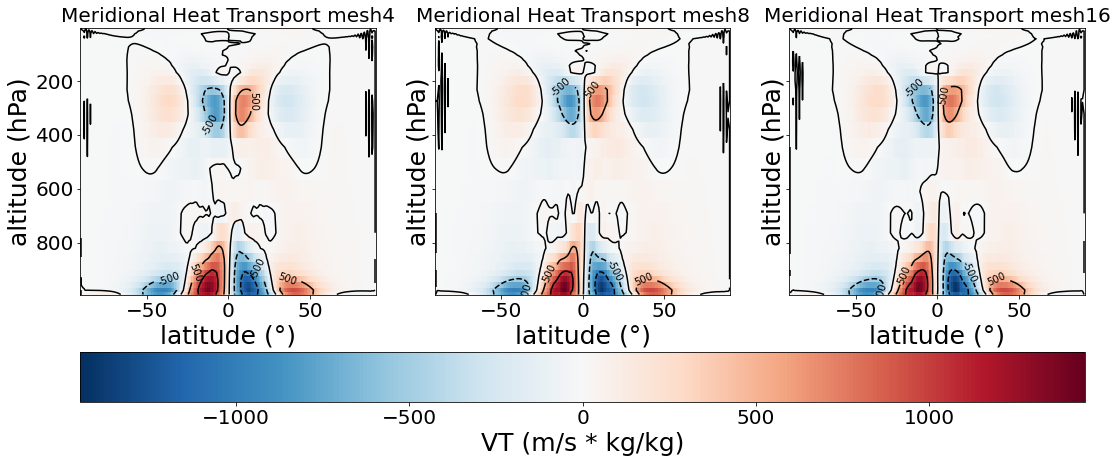

In [29]:
# Overall: plots separately the meridional heat transport for each case (altitude evolution)

# Creates an empty list to store data
plot_data = []
for case in config :
    # Groups the case's atmospheric time series dictionary by year, calculates the mean
    ds_case = ts_dict_atm[case].groupby('time.year').mean('time')
    VT = ds_case['VT'].mean('year').mean('lon')
    plot_data.append((case,VT))

# Shared colour limits for the same scale across all plots
# Calculates the min and max value of all VT for the colorbar
vmin = min(float(VT.min().values) for (case, VT) in plot_data)
vmax = max(float(VT.max().values) for (case, VT) in plot_data)
lim = max(abs(vmin),abs(vmax))

fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=True)

for ax, (case, VT) in zip(axes, plot_data):
    lat = VT['lat']
    lev = VT['lev']

    # Draws contours
    cs = ax.contour(lat, lev, VT, levels=5, linestyles=None, colors='k')
    ax.clabel(cs, levels=cs.levels[::2], fmt="%d", fontsize=10, inline=True)
    
    # Draws the colormap
    im = ax.pcolormesh(lat, lev, VT, cmap='RdBu_r', vmin=-lim, vmax=lim, shading='auto')
    
    ax.set_title(f'Meridional Heat Transport {case}',fontsize=20)
    ax.set_xlabel('latitude (°)',fontsize=25)
    ax.set_ylabel('altitude (hPa)',fontsize=25)
    ax.tick_params(labelsize=20)
    # Reverts y-axis
    ax.set_ylim(lev.max().values, lev.min().values)

# Manages colorbar
cb = fig.colorbar(im, ax=axes, orientation='horizontal')
cb.set_label('VT (m/s * kg/kg)',fontsize=25)
cb.ax.tick_params(labelsize=20)

plt.show()
plt.close()